In [35]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from xgboost import plot_importance
import matplotlib.pyplot as plt

model_data = pd.read_csv("data/processed/test_training_data.csv")
print(model_data.shape)
model_data.head()

(1963, 18)


,"last_name, first_name",player_id,year,hit,single,double,triple,home_run,strikeout,walk,b_rbi,b_total_bases,r_total_stolen_base,r_run,season,fantasy_points,next_season_points,next_season
0,"Abrams, CJ",682928,2022,70,54,12,2,2,50,5,21,92,7,33,2022,108,340.0,2023.0
1,"Abrams, CJ",682928,2023,138,86,28,6,18,118,32,64,232,47,83,2023,340,321.0,2024.0
2,"Abrams, CJ",682928,2024,133,78,29,6,20,128,40,65,234,31,79,2024,321,346.0,2025.0
3,"Abreu, José",547989,2015,178,111,34,3,30,140,39,101,308,0,88,2015,396,381.0,2016.0
4,"Abreu, José",547989,2016,183,125,32,1,25,125,47,100,292,0,67,2016,381,459.0,2017.0


In [2]:
model_data.isnull().sum() #find empty data

last_name, first_name    0
player_id                0
year                     0
hit                      0
single                   0
double                   0
triple                   0
home_run                 0
strikeout                0
walk                     0
b_rbi                    0
b_total_bases            0
r_total_stolen_base      0
r_run                    0
season                   0
fantasy_points           0
next_season_points       0
next_season              0
dtype: int64

In [3]:
model_data["gap"] = model_data["next_season"] - model_data["year"]
model_data["gap"].value_counts()

gap
1.0    1625
2.0     268
3.0      53
4.0      11
6.0       3
5.0       3
Name: count, dtype: int64

In [4]:
model_data = model_data[model_data["gap"] == 1.0].copy() #remove year gaps (ex: 2021 - 2023)
print(model_data.shape)
model_data["gap"].value_counts()

(1625, 19)


gap
1.0    1625
Name: count, dtype: int64

In [5]:
features = [
    "single",
    "double", 
    "triple",
    "home_run",
    "strikeout",
    "walk",
    "b_rbi",
    "r_total_stolen_base",
    "r_run",
    "fantasy_points"
]
target = "next_season_points"

x = model_data[features]
y = model_data[target]

print(x.shape)
print(y.describe())

(1625, 10)
count    1625.000000
mean      281.920615
std       108.665848
min        58.000000
25%       197.000000
50%       270.000000
75%       356.000000
max       707.000000
Name: next_season_points, dtype: float64


In [6]:
train = model_data[model_data["year"] < 2024] #data used for traning
test = model_data[model_data["year"] == 2024] #data used for testing (precict 2025 points)

x_train = train[features] #current season points (pre-2024)
x_test = test[features]
y_train = train[target] #next season points (pre-2024)
y_test = test[target]

print(f"training row: {len(train)}")
print(f"testing row: {len(test)}")

training row: 1426
testing row: 199


In [7]:
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
model.fit(x_train, y_train)

y_predict = model.predict(x_test)

mae = mean_absolute_error(y_test, y_predict)
print(f"Mean Absolute Error: {mae:.1f} fantasy points")

Mean Absolute Error: 70.1 fantasy points


In [8]:
result1 = test[["last_name, first_name", "year", "fantasy_points"]].copy()
result1["predicted"] = y_predict.round(1)
result1["actual"] = y_test.values
result1["error"] = (result1["predicted"] - result1["actual"]).abs()
result1.sort_values("error", ascending=False).head(10)

,"last_name, first_name",year,fantasy_points,predicted,actual,error
1435,"Raleigh, Cal",2024,311,275.899994,509.0,233.100006
1350,"Perdomo, Geraldo",2024,211,284.399994,512.0,227.600006
938,"Judge, Aaron",2024,630,374.299988,599.0,224.700012
1519,"Rodríguez, Julio",2024,282,220.899994,432.0,211.100006
184,"Bichette, Bo",2024,121,206.399994,406.0,199.600006
1751,"Tatis Jr., Fernando",2024,256,247.199997,439.0,191.800003
209,"Bohm, Alec",2024,366,435.700012,251.0,184.700012
1289,"Ohtani, Shohei",2024,653,388.000000,570.0,182.000000
49,"Alonso, Pete",2024,359,258.899994,440.0,181.100006
1658,"Soler, Jorge",2024,294,281.500000,107.0,174.500000


In [18]:
data_set_2 = pd.read_csv("../data/raw/savant_model2.csv")

print(data_set_2.shape)
data_set_2.head()

(2769, 16)


,"last_name, first_name",player_id,year,player_age,pa,home_run,k_percent,bb_percent,r_total_stolen_base,xba,xslg,xwoba,sweet_spot_percent,barrel_batted_rate,hard_hit_percent,avg_hyper_speed
0,"Hunter, Torii",116338,2015,39,567,22,18.5,6.2,2,0.229,0.370,0.290,28.5,5.6,34.9,93.393480
1,"Ortiz, David",120074,2015,39,614,37,15.5,12.5,0,0.301,0.616,0.420,34.8,14.6,49.1,96.053058
2,"Rodriguez, Alex",121347,2015,39,620,33,23.4,13.5,4,0.247,0.494,0.368,31.4,11.8,43.9,95.014380
3,"Ramirez, Aramis",133380,2015,37,516,17,13.2,6.0,1,0.240,0.405,0.304,33.5,6.1,34.5,92.944763
4,"Beltré, Adrian",134181,2015,36,619,18,10.5,6.6,1,0.295,0.482,0.360,35.7,5.8,40.4,93.842412


In [23]:
model_data_2 = model_data.merge(data_set_2[[
    "player_id", "year", "player_age", "pa", "k_percent", "bb_percent", "xba", "xslg", 
    "xwoba", "sweet_spot_percent", "barrel_batted_rate","hard_hit_percent", "avg_hyper_speed"]],
    on=["player_id", "year"], how="inner"
)
print(model_data_2.shape)
model_data_2.head()



(1963, 29)


,"last_name, first_name",player_id,year,hit,single,double,triple,home_run,strikeout,walk,...,pa,k_percent,bb_percent,xba,xslg,xwoba,sweet_spot_percent,barrel_batted_rate,hard_hit_percent,avg_hyper_speed
0,"Abrams, CJ",682928,2022,70,54,12,2,2,50,5,...,302,16.6,1.7,0.244,0.327,0.272,28.6,2.1,30.7,92.612726
1,"Abrams, CJ",682928,2023,138,86,28,6,18,118,32,...,614,19.2,5.2,0.243,0.402,0.304,32.6,6.9,35.9,93.426357
2,"Abrams, CJ",682928,2024,133,78,29,6,20,128,40,...,602,21.3,6.6,0.243,0.413,0.320,33.0,7.0,40.7,93.910198
3,"Abreu, José",547989,2015,178,111,34,3,30,140,39,...,668,21.0,5.8,0.270,0.456,0.338,30.4,10.6,41.8,95.406299
4,"Abreu, José",547989,2016,183,125,32,1,25,125,47,...,695,18.0,6.8,0.280,0.467,0.348,32.7,8.6,39.4,94.406076


In [29]:
#model_data["gap"] = model_data["next_season"] - model_data["year"]
model_data_2["gap"] = model_data_2["next_season"] - model_data_2["year"]
model_data_2 = model_data_2[model_data_2["gap"] == 1.0].copy()
print(model_data_2.shape)
print(model_data_2.columns.tolist())

(1625, 30)
['last_name, first_name', 'player_id', 'year', 'hit', 'single', 'double', 'triple', 'home_run', 'strikeout', 'walk', 'b_rbi', 'b_total_bases', 'r_total_stolen_base', 'r_run', 'season', 'fantasy_points', 'next_season_points', 'next_season', 'player_age', 'pa', 'k_percent', 'bb_percent', 'xba', 'xslg', 'xwoba', 'sweet_spot_percent', 'barrel_batted_rate', 'hard_hit_percent', 'avg_hyper_speed', 'gap']


In [32]:
features_2 = ["player_age", "pa", "home_run", "r_total_stolen_base", "k_percent", 
            "bb_percent", "xba", "xslg", "xwoba", "sweet_spot_percent", "barrel_batted_rate",
            "hard_hit_percent", "avg_hyper_speed", "fantasy_points"]
target = "next_season_points"

x_train_2 = model_data_2[model_data_2["year"] < 2024][features_2]
x_test_2 = model_data_2[model_data_2["year"] == 2024][features_2]
y_train_2 = model_data_2[model_data_2["year"] < 2024][target]
y_test_2 = model_data_2[model_data_2["year"] == 2024][target]

print(f"training: {len(x_train_2)}")
print(f"testing: {len(x_test_2)}")

training: 1426
testing: 199


In [33]:
model_2 = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
model_2.fit(x_train_2, y_train_2)
y_prediction_2 = model_2.predict(x_test_2)

mae_2 = mean_absolute_error(y_test_2, y_prediction_2)
print(f"Model 1 MAE: {mae: .1f}")
print(f"Model 2 MAE: {mae_2: .1f}")
print(f"Difference: {mae - mae_2: .1f}")

Model 1 MAE:  70.1
Model 2 MAE:  66.2
Difference:  4.0


In [34]:
result2 = test[["last_name, first_name", "year", "fantasy_points"]].copy()
result2["predicted"] = y_prediction_2.round(1)
result2["actual"] = y_test_2.values
result2["error"] = (result2["predicted"] - result2["actual"]).abs()
result2.sort_values("error", ascending=False).head(10)

,"last_name, first_name",year,fantasy_points,predicted,actual,error
1350,"Perdomo, Geraldo",2024,211,264.100006,512.0,247.899994
1435,"Raleigh, Cal",2024,311,298.200012,509.0,210.799988
938,"Judge, Aaron",2024,630,392.600006,599.0,206.399994
1401,"Polanco, Jorge",2024,149,141.500000,341.0,199.500000
1289,"Ohtani, Shohei",2024,653,375.100006,570.0,194.899994
1796,"Tovar, Ezequiel",2024,297,341.500000,149.0,192.500000
1681,"Springer, George",2024,293,255.199997,445.0,189.800003
1587,"Schwarber, Kyle",2024,406,323.700012,504.0,180.299988
401,"Cowser, Colton",2024,258,295.200012,115.0,180.200012
260,"Buxton, Byron",2024,232,187.600006,366.0,178.399994


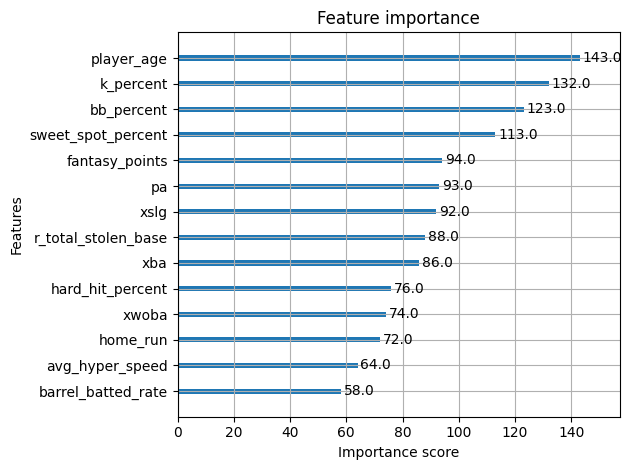

In [36]:
plot_importance(model_2 , max_num_features=14)
plt.tight_layout()
plt.show()